# Modelleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

## 1. Veri Yükleme

In [2]:
df = pd.read_csv("../data/processed/processed.csv")
print(df.shape)
df.head()

(20025, 17)


,log_market_value,age,height_in_cm,total_goals,total_assists,total_matches,total_yellow_cards,total_red_cards,goals_per_match,assists_per_match,minutes_per_match,position,position_encoded,sub_position_encoded,foot_encoded,country_of_citizenship_encoded,player_club_domestic_competition_id_encoded
0,12.206078,1.304366,-0.938488,0.018086,0.060829,2.505714,2.603434,-0.402174,-0.402985,-0.409438,0.624263,Midfield,3,4,1,61,11
1,14.508658,0.894712,-0.938488,3.674083,6.667888,3.375239,0.611030,-0.402174,1.250623,2.354432,0.105259,Midfield,3,0,2,59,15
2,12.206078,1.509193,1.008485,-0.388136,-0.454007,0.075503,-0.385172,1.206924,-0.642527,-0.687695,1.319083,Goalkeeper,2,5,1,144,8
3,12.611541,1.509193,-0.339419,1.642974,0.489859,1.335199,0.943098,1.206924,1.220573,0.105852,-0.168983,Attack,0,3,2,125,21
4,12.206078,1.714020,1.008485,-0.388136,-0.454007,-0.314668,-0.053104,1.206924,-0.642527,-0.687695,1.375910,Defender,1,2,1,115,24


## 2. Girdi ve Çıktı Ayrımı

In [3]:
# girdi ve çıktı ayarlama
X = df.drop(columns=["log_market_value", "position"])
y = df["log_market_value"]

print("Veri boyutu:", X.shape)

Veri boyutu: (20025, 15)


## 3. Eğitim ve Test Ayrımı

In [4]:
# %80 eğitim, %20 test ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (16020, 15)
Test seti: (4005, 15)


## 4. Model 1: Doğrusal Regresyon (Linear Regression)

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Sonuçları:")
print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²: {r2_lr:.4f}")

Linear Regression Sonuçları:
MAE: 0.8195
RMSE: 1.0300
R²: 0.4980


## 5. Model 2: Rastgele Orman Regresörü (Random Forest Regressor)

In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Sonuçları:")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")

Random Forest Sonuçları:
MAE: 0.6120
RMSE: 0.7832
R²: 0.7098


## 6. Mevkiye Göre Modelleme

In [7]:
# mevki tabanlı kıyaslama
position_features = {
    "Goalkeeper": [
        "age", "height_in_cm", "total_matches", "minutes_per_match",
        "total_yellow_cards", "total_red_cards",
        "position_encoded", "foot_encoded",
        "country_of_citizenship_encoded", "player_club_domestic_competition_id_encoded"
    ],
    "Defender": [
        "age", "height_in_cm", "total_matches", "minutes_per_match",
        "total_yellow_cards", "total_red_cards",
        "position_encoded", "sub_position_encoded", "foot_encoded",
        "country_of_citizenship_encoded", "player_club_domestic_competition_id_encoded"
    ],
    "Midfield": [
        "age", "total_goals", "total_assists", "total_matches",
        "goals_per_match", "assists_per_match", "minutes_per_match",
        "total_yellow_cards", "total_red_cards",
        "position_encoded", "sub_position_encoded", "foot_encoded",
        "country_of_citizenship_encoded", "player_club_domestic_competition_id_encoded"
    ],
    "Attack": [
        "age", "total_goals", "total_assists", "total_matches",
        "goals_per_match", "assists_per_match", "minutes_per_match",
        "total_yellow_cards", "total_red_cards",
        "sub_position_encoded", "foot_encoded",
        "country_of_citizenship_encoded", "player_club_domestic_competition_id_encoded"
    ]
}

positions = df["position"].unique()
position_results = []
position_models = {}

for position in sorted(positions):
    df_pos = df[df["position"] == position].copy()
    X_pos = df_pos[position_features[position]]
    y_pos = df_pos["log_market_value"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_pos, y_pos, test_size=0.2, random_state=42
    )

    lr_pos = LinearRegression()
    lr_pos.fit(X_tr, y_tr)
    y_pred_lr_pos = lr_pos.predict(X_te)
    cv_lr_pos = np.sqrt(-cross_val_score(
        lr_pos, X_tr, y_tr, cv=5, scoring="neg_mean_squared_error"
    ))

    rf_pos = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_pos.fit(X_tr, y_tr)
    y_pred_rf_pos = rf_pos.predict(X_te)
    cv_rf_pos = np.sqrt(-cross_val_score(
        rf_pos, X_tr, y_tr, cv=5, scoring="neg_mean_squared_error"
    ))

    position_results.append({
        "Mevki": position,
        "LR RMSE": np.sqrt(mean_squared_error(y_te, y_pred_lr_pos)),
        "RF RMSE": np.sqrt(mean_squared_error(y_te, y_pred_rf_pos)),
        "LR MAE": mean_absolute_error(y_te, y_pred_lr_pos),
        "RF MAE": mean_absolute_error(y_te, y_pred_rf_pos),
        "LR R²": r2_score(y_te, y_pred_lr_pos),
        "RF R²": r2_score(y_te, y_pred_rf_pos),
        "LR CV RMSE": cv_lr_pos.mean(),
        "RF CV RMSE": cv_rf_pos.mean()
    })
    position_models[position] = {"lr": lr_pos, "rf": rf_pos}
    print(f"{position:12} | LR R²: {position_results[-1]['LR R²']:.4f} | RF R²: {position_results[-1]['RF R²']:.4f}")

position_df = pd.DataFrame(position_results)
print()
print(position_df.to_string(index=False))

Attack       | LR R²: 0.4967 | RF R²: 0.6646
Defender     | LR R²: 0.4774 | RF R²: 0.6752
Goalkeeper   | LR R²: 0.3818 | RF R²: 0.6550
Midfield     | LR R²: 0.5209 | RF R²: 0.7040

     Mevki  LR RMSE  RF RMSE   LR MAE   RF MAE    LR R²    RF R²  LR CV RMSE  RF CV RMSE
    Attack 1.019787 0.832491 0.818546 0.646002 0.496657 0.664568    1.057739    0.859854
  Defender 1.016543 0.801370 0.811642 0.627987 0.477372 0.675206    1.023388    0.812525
Goalkeeper 1.032984 0.771639 0.793754 0.613359 0.381819 0.655050    1.015598    0.836626
  Midfield 1.060954 0.833946 0.846375 0.650857 0.520943 0.704015    1.034245    0.849165


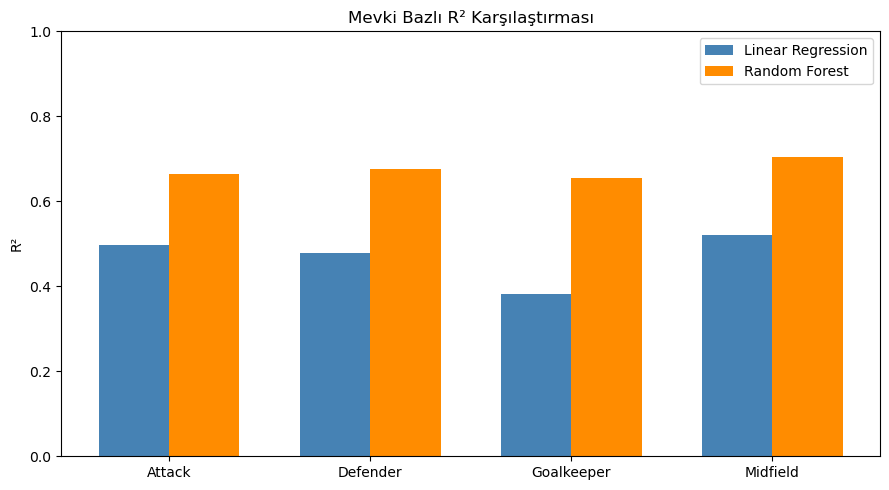

In [8]:
x = range(len(position_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], position_df["LR R²"], width, label="Linear Regression", color="steelblue")
ax.bar([i + width/2 for i in x], position_df["RF R²"], width, label="Random Forest", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(position_df["Mevki"])
ax.set_ylabel("R²")
ax.set_title("Mevki Bazlı R² Karşılaştırması")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("../visuals/position_r2.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Çapraz Doğrulama (Cross Validation)

In [9]:
# 5 katlı çapraz doğrulama (negatif MSE -> RMSE)
cv_rmse_lr = np.sqrt(-cross_val_score(
    lr, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
))

cv_rmse_rf = np.sqrt(-cross_val_score(
    rf, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
))

print("Linear Regression CV RMSE: {:.4f} ± {:.4f}".format(
    cv_rmse_lr.mean(), cv_rmse_lr.std()))
print("Random Forest CV RMSE: {:.4f} ± {:.4f}".format(
    cv_rmse_rf.mean(), cv_rmse_rf.std()))

Linear Regression CV RMSE: 1.0405 ± 0.0097
Random Forest CV RMSE: 0.7993 ± 0.0100


## 8. Model Karşılaştırması

In [10]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R²": [r2_lr, r2_rf],
    "CV RMSE": [cv_rmse_lr.mean(), cv_rmse_rf.mean()],
    "CV Std": [cv_rmse_lr.std(), cv_rmse_rf.std()]
})

print(results.to_string(index=False))

            Model      MAE     RMSE       R²  CV RMSE   CV Std
Linear Regression 0.819498 1.029959 0.498030 1.040549 0.009682
    Random Forest 0.611999 0.783189 0.709751 0.799330 0.010005


## 9. Görselleştirme

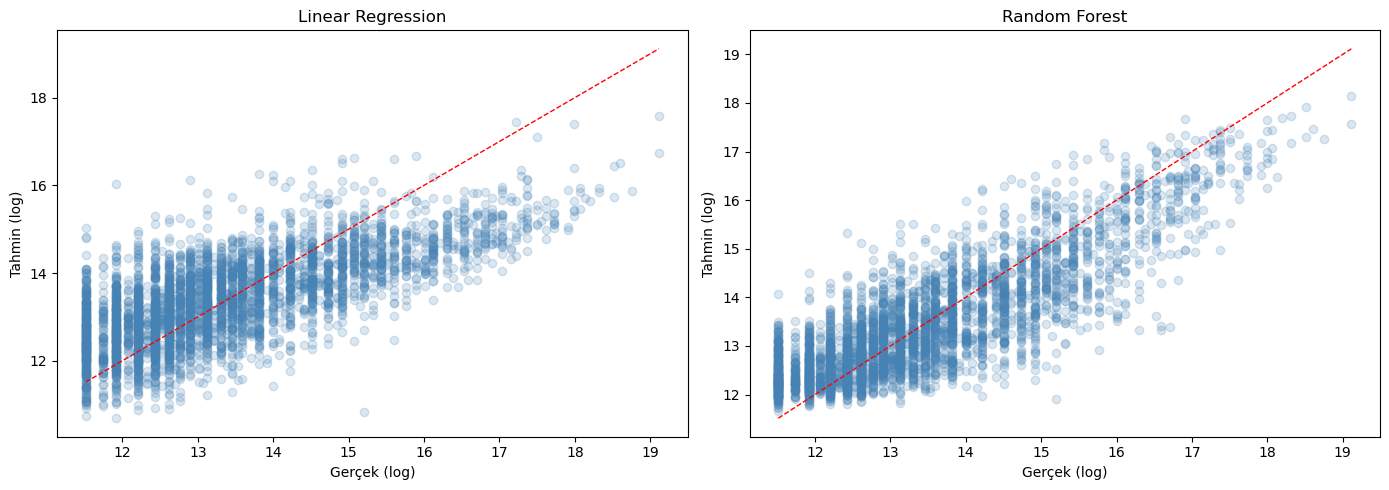

In [11]:
# gerçek ve tahmin karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Linear Regression", "Random Forest"]
):
    ax.scatter(y_test, y_pred, alpha=0.2, color="steelblue")
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", linewidth=1)
    ax.set_xlabel("Gerçek (log)")
    ax.set_ylabel("Tahmin (log)")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("../visuals/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

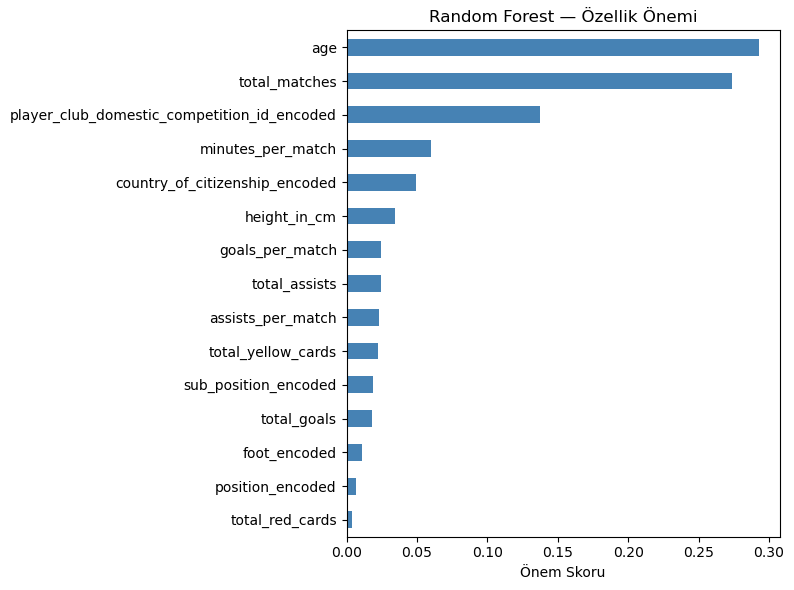

In [12]:
# random forest özellik önemi
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="steelblue")
plt.xlabel("Önem Skoru")
plt.title("Random Forest — Özellik Önemi")
plt.tight_layout()
plt.savefig("../visuals/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Hata Analizi

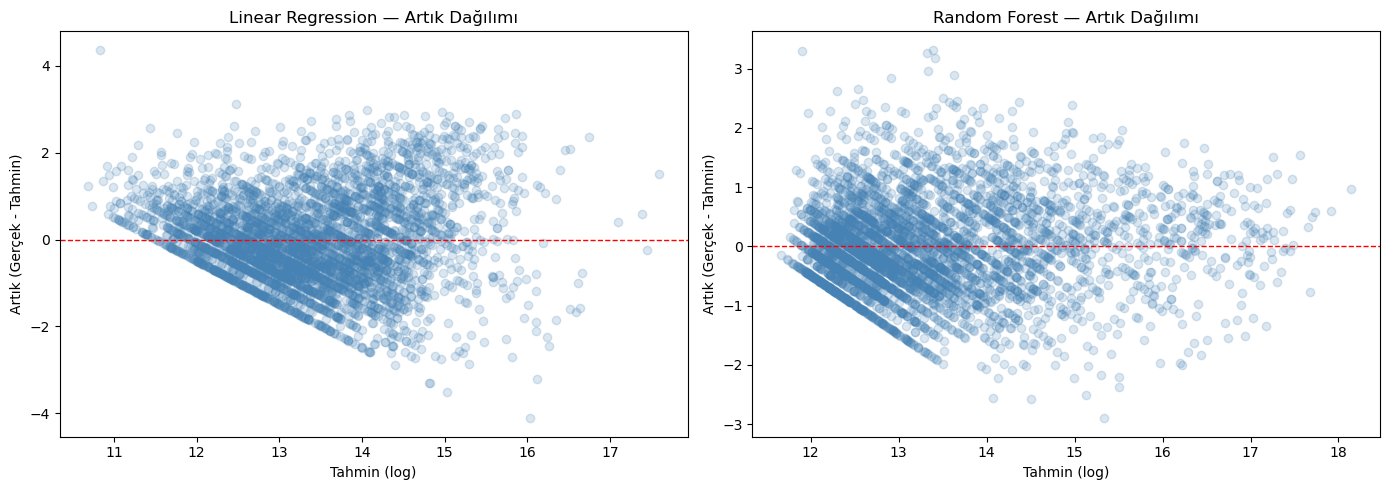

In [13]:
# artık (residual) dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Linear Regression", "Random Forest"]
):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.2, color="steelblue")
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Tahmin (log)")
    ax.set_ylabel("Artık (Gerçek - Tahmin)")
    ax.set_title(f"{title} — Artık Dağılımı")

plt.tight_layout()
plt.savefig("../visuals/residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Tahmin Yorumu

In [14]:
# log değerlerini Euro değerine çevirme
y_test_eur = np.expm1(y_test)
y_pred_lr_eur = np.expm1(y_pred_lr)
y_pred_rf_eur = np.expm1(y_pred_rf)

# örnek tahminler
sample = pd.DataFrame({
    "Gerçek (€)": y_test_eur.values[:10],
    "LR Tahmini (€)": y_pred_lr_eur[:10],
    "RF Tahmini (€)": y_pred_rf_eur[:10]
})
sample = sample.map(lambda x: f"{x:,.0f}")
print("\nÖrnek Tahminler:")
print(sample.to_string(index=False))


Örnek Tahminler:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
   100,000        206,059        232,958
 2,000,000        214,528        201,742
   250,000        300,996        169,031
   700,000        565,786        548,834
60,000,000      3,181,473     14,915,111
   200,000        855,985        356,994
   350,000        650,124        951,420
   500,000        299,873        297,977
   150,000        404,095        437,067
   200,000        753,007        301,266


In [15]:
# mevkiye göre örnek tahminler
for position in sorted(df["position"].unique()):
    df_pos_all = df[df["position"] == position]
    X_pos_all = df_pos_all[position_features[position]]
    y_pos_all = df_pos_all["log_market_value"]

    _, X_te_pos, _, y_te_pos = train_test_split(
        X_pos_all, y_pos_all, test_size=0.2, random_state=42
    )

    lr_pos_sample = position_models[position]["lr"]
    rf_pos_sample = position_models[position]["rf"]

    pred_lr_eur = np.expm1(lr_pos_sample.predict(X_te_pos[:3]))
    pred_rf_eur = np.expm1(rf_pos_sample.predict(X_te_pos[:3]))
    actual_eur = np.expm1(y_te_pos.values[:3])

    sample_pos = pd.DataFrame({
        "Gerçek (€)": actual_eur,
        "LR Tahmini (€)": pred_lr_eur,
        "RF Tahmini (€)": pred_rf_eur
    }).map(lambda x: f"{x:,.0f}")
    print(f"\n{position}:")
    print(sample_pos.to_string(index=False))


Attack:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
   175,000        298,964        255,249
   150,000        167,745        216,386
 2,000,000        632,958        628,452

Defender:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
 5,000,000      2,611,928      2,896,591
   350,000        318,186        272,906
   550,000        323,249        335,162

Goalkeeper:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
   150,000        811,826        446,612
 1,000,000      1,454,522        798,195
   300,000        218,037        372,374

Midfield:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
   250,000      3,761,783      1,427,242
   250,000        377,499        324,682
   400,000        329,638        258,772


## 12. Bulgular
- Random Forest, tüm metriklerde Linear Regresssion'ı geride bırakmıştır; RMSE 1.03'ten 0.79'a, R² ise 0.47'den 0.69'a yükselmiştir.
- Random Forest modeli varyansın %69'ını açıklamaktadır; bu düzey transfer piyasasındaki öznel etkenler göz önüne alındığında tatmin edici bir performans olarak değerlendirilebilir.
- 5 katlı çapraz doğrulama sonuçları (CV RMSE: 0.7953 ± 0.0085) test seti sonuçlarıyla örtüşmektedir; modelin genelleme kapasitesi güçlüdür ve aşırı öğrenme gözlemlenmemiştir.
- Linear Regression, piyasa değerinin doğrusal olmayan yapısını yeterince yakalayamamış; tahminler özellikle yüksek değerli futbolcularda belirgin sapma göstermiştir.
- Mevkiye göre modelleme sonuçları genel modelle tutarlıdır; Random Forest her mevkide Linear Regression'ı geride bırakmış, en yüksek R² forvet (0.67), en düşük kaleci (0.63) modelinde gözlemlenmiştir.
- Kaleci modelinin görece düşük performansı, gol ve asist gibi temel performans göstergelerinin bu mevki için anlamsız olmasından kaynaklanmaktadır.
- Artık dağılım analizi, Random Forest'ın hata dağılımının daha dengeli olduğunu ortaya koymaktadır; bununla birlikte her iki modelde de yüksek değerli futbolcularda tahmin güçlüğü gözlemlenmiştir.
- Tahmin yorumu tablosu, Random Forest'ın Euro bazında gerçek değerlere daha yakın sonuçlar ürettiğini somut örneklerle göstermektedir.